In [31]:
import serial
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

plt.style.use('dark_background')


In [9]:
with serial.Serial("COM26", 115200, rtscts=False) as ser:
    ser.write(b'hello\n')
    l = ser.readline().decode()
    print(l)


[  2608][I][esp32-hal-i2c.c:75] i2cInit(): Initialising ESP-ROM:BOOT



In [32]:
cmd = '''
reset();
config(0, 110, 0, 5, 5, 5);
for (i = 0; i < 10; i++){
    set_arr(1, 1, 200, 500, i * 10, 1);
    run();
    set_arr(1, 1, 200, 200, 0, 1);
    run();
}


'''

cmd_str = "C:" + cmd + "?"
cmd_str

'C:\nreset();\nconfig(0, 110, 0, 5, 5, 5);\nfor (i = 0; i < 10; i++){\n    set_arr(1, 1, 200, 500, i * 10, 1);\n    run();\n    set_arr(1, 1, 200, 200, 0, 1);\n    run();\n}\n\n\n?'

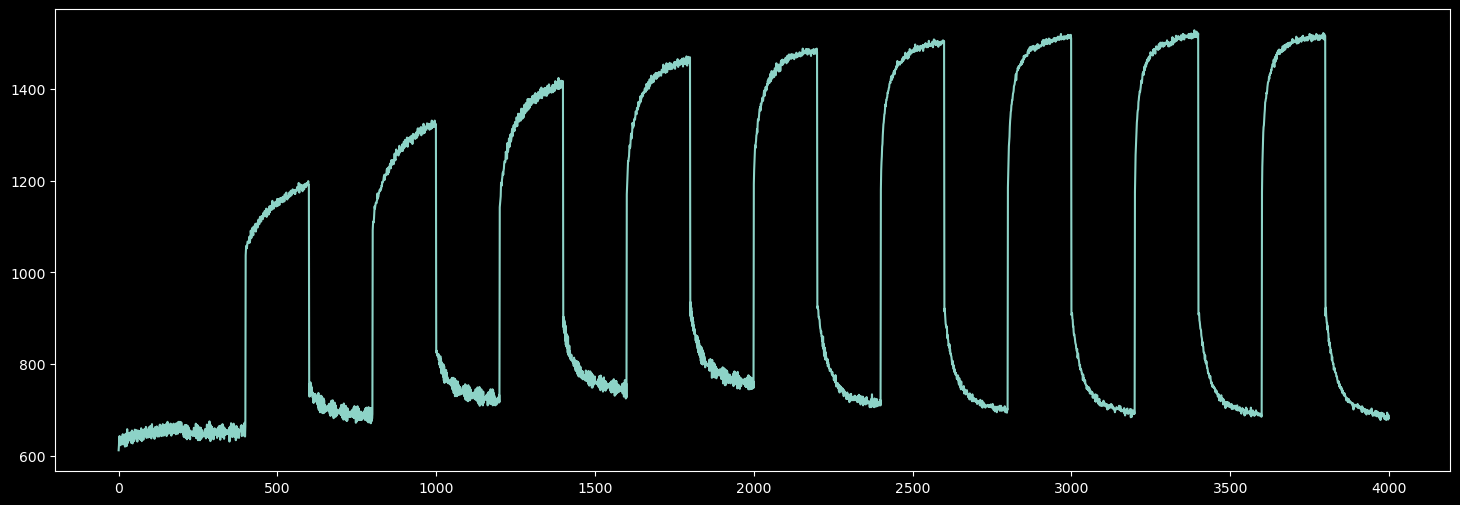

In [33]:
fig, ax = plt.subplots(1, 1, figsize = (18, 6))
line = ax.plot([])[0]
outputs = ""
with serial.Serial("COM26", 115200) as ser:
    start_timer = time.time()
    ser.write(cmd_str.encode())
    arr = []
    last_update_time,  last_update_length = 0, 0

    while (time.time() - start_timer < 1):
        if ser.in_waiting > 2:
            start_timer = time.time()
            l = ser.readline().decode().strip()
            if l[0] == '[':
                outputs += l + "\n"
            elif l[0].isdigit() and l[-1].isdigit():
                if l.count(',') == 3:
                    _arr = np.fromstring(l, sep = ',', dtype=int).tolist()
                    arr.append(_arr)
        else:
            if (len(arr) - last_update_length > 1) and (time.time() - last_update_time > .01):
                plot_arr = np.array(arr)
                line.set_data(np.arange(plot_arr.shape[0]), plot_arr[:, 0])
                ax.autoscale_view(True, True) 
                ax.relim()
                
                last_update_length = len(arr)
                last_update_time = time.time()
                display(fig)
                clear_output(wait=True)

                plt.pause(0.0001)

                
plt.show()    

In [35]:
print(outputs)

[ 46442][V][u_adpd6100.cpp:584] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 6 bytes
[ 46444][V][u_adpd6100.cpp:631] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 8 bytes
[ 46453][I][PAM.cpp:35] detector_preset_1(): [PAM] Preset 1 set
[ 46458][V][do_c_command.cpp:79] detector_preset(): [DO_C] ADPD detector preset with current: 110
[ 46467][V][do_c_command.cpp:38] arr_set(): [DO_C] Set line 0 to type 1 with 200 x 500Hz samples, actinic:0, sub:1
[ 46477][V][PAM.cpp:72] run_preprocess(): [PAM] Run type:1, number:200, freq: 500, actinic: 0, subfactor 1
[ 46486][V][PAM.cpp:131] run_arr(): [PAM] Sample: 200, ref: 200, amb: 200, dark: 200
[ 46493][V][PAM.cpp:91] data_allocation(): [PAM] Allocation F_data: 800 bytes
[ 46500][V][PAM.cpp:95] data_allocation(): [PAM] Allocation R_data: 800 bytes
[ 46507][V][PAM.cpp:99] data_allocation(): [PAM] Allocation A_data: 800 bytes
[ 46514][V][PAM.cpp:103] data_allocation(): [PAM] Allocatio

In [76]:
2*256+88

600

In [35]:
arr = [[1, 0, 0, 200, 0, 50, 0, 1],
       [1, 0, 0, 200, 0, 50, 50, 1],
       [1, 0, 0, 200, 0, 50, 0, 1]
       ]


arr = np.reshape(arr, (-1, 8)).astype(np.uint8)

cmd_int = [arr.shape[0]] + arr.flatten().tolist()
cmd_str = "run,"
for i in cmd_int:
    cmd_str += str(i)
    cmd_str += ","
cmd_str = cmd_str.rstrip(',') + '\r\n'
cmd_str

'run,3,1,0,0,200,0,50,0,1,1,0,0,200,0,50,50,1,1,0,0,200,0,50,0,1\r\n'

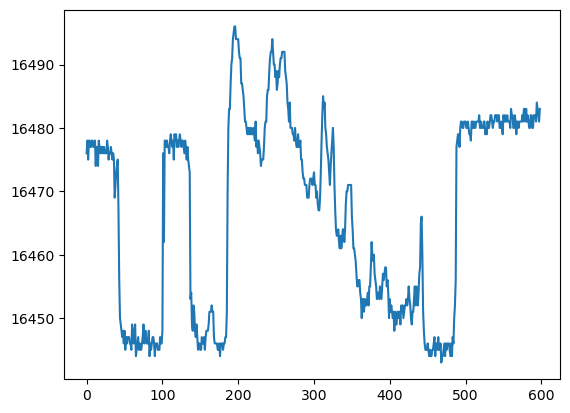

In [38]:
fig, ax = plt.subplots(1, 1)
line = ax.plot([])[0]

with serial.Serial("COM4", 115200) as ser:
    start_timer = time.time()
    ser.write(cmd_str.encode())
    arr = []
    last_update_time,  last_update_length = 0, 0

    while (time.time() - start_timer < 1):
        if ser.in_waiting > 2:
            start_timer = time.time()
            l = ser.readline().decode().strip()
            if l[0] == '[':
                print(l)
            elif l[0].isdigit() and l[-1].isdigit():
                if l.count(',') == 3:
                    _arr = np.fromstring(l, sep = ',', dtype=int).tolist()
                    arr.append(_arr)
        else:
            if (len(arr) - last_update_length > 1) and (time.time() - last_update_time > .01):
                plot_arr = np.array(arr)
                line.set_data(np.arange(plot_arr.shape[0]), plot_arr[:, 2])
                ax.autoscale_view(True, True)
                ax.relim()
                
                last_update_length = len(arr)
                last_update_time = time.time()
                display(fig)
                clear_output(wait=True)

                plt.pause(0.0001)

                
   

    

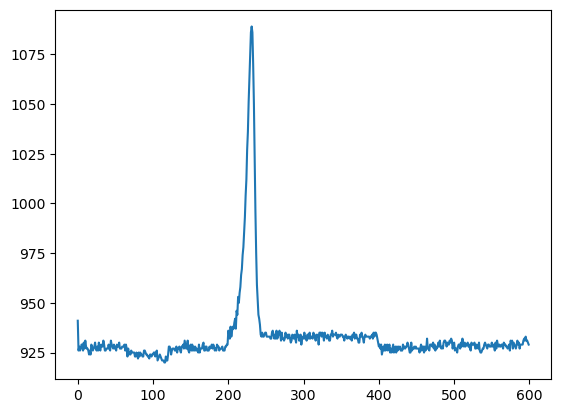

In [29]:
plt.plot(plot_arr[:, 1])

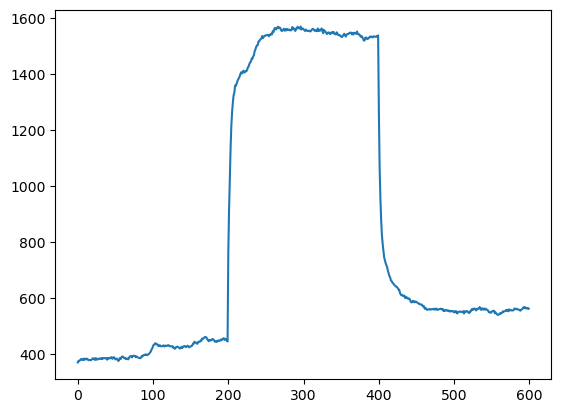

In [58]:
fig, ax = plt.subplots(1, 1)
line = ax.plot(arr[:, 0])

In [62]:
line